## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [27]:
import faiss

corpus=[
 "AI detects water pollution in rivers","Machine learning predicts urban floods",
 "Solar panels generate clean renewable energy","Sensors monitor air quality in cities",
 "Drones map deforestation from above","AI optimises electricity grid efficiency",
 "Satellite data tracks melting glaciers","Models forecast extreme weather events",
 "Smart irrigation saves water on farms","Neural nets classify recyclable waste",
 "Wind turbines convert wind into power","AI reduces factory carbon emissions"]

emb = embed(corpus)                       # (N, d)
index = faiss.IndexFlatL2(emb.shape[1])   # exact L2 (Euclidean) search
index.add(emb)
print("indexed", index.ntotal, "documents")

def search(query, k=3):
    q = embed(query)
    D, I = index.search(q, k)             # distances + indices
    return [(corpus[i], float(d)) for i,d in zip(I[0], D[0])]

for doc,dist in search("how does AI find pollution in water", k=3):
    print(f"  {dist:6.3f}  {doc}")

indexed 12 documents
   0.664  AI detects water pollution in rivers
   1.324  AI optimises electricity grid efficiency
   1.324  AI reduces factory carbon emissions


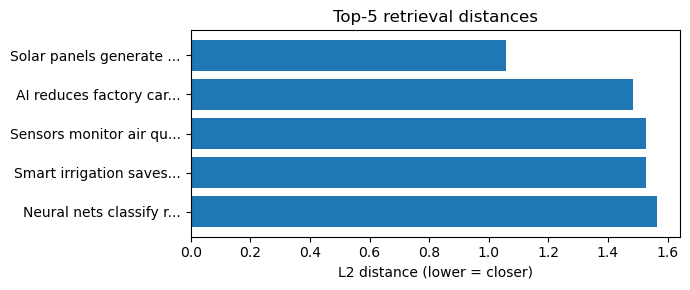

In [28]:
import matplotlib.pyplot as plt

res = search("clean renewable power", k=5)
labels = [d[:22] + "..." for d, _ in res]
dists  = [v for _, v in res]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(labels, dists)
ax.invert_yaxis()                       # best match on top
ax.set_xlabel("L2 distance (lower = closer)")
ax.set_title("Top-5 retrieval distances")
fig.tight_layout()
plt.show()

**Reflection**
- How does L2 distance differ from cosine similarity?
 - Answer: L2 measures straight-line distance (sensitive to vector length); cosine measures the angle (length-invariant), which is what you usually want for text. if you
L2-normalise every vector first, ranking by L2 gives the same order as cosine — which is why the fallback embedder normalises.

- How would results change if you normalize embeddings?
 - Answer :Normalising embeddings removes magnitude effects so a long document doesn't look "far" just because it has more words; results become purely about direction/meaning.

**Insight (semantic vs keyword):** keyword search needs literal word overlap; embedding search matches meaning, so paraphrases and synonyms retrieve correctly. The trade-off is that embeddings can over-generalise and need a model and index.

## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [ ]:
import chromadb
client = chromadb.Client()
col = client.create_collection("ai_water_docs")

docs   = ["AI detects water pollution","Sensors track river contamination",
          "Solar power for clean energy","Drones map deforestation",
          "Smart irrigation saves water","AI forecasts floods",
          "Neural nets sort recyclables","Glacier melt tracked by satellite",
          "Wind turbines make power","AI cuts factory emissions"]
metas  = [{"title":f"doc{i}","source":"scientific" if i%2==0 else "news"}
          for i in range(len(docs))]
col.add(documents=docs, metadatas=metas, ids=[f"id{i}" for i in range(len(docs))])

for q in ["How does AI detect pollution?","ways to make clean energy",
          "predicting natural disasters"]:
    r = col.query(query_texts=[q], n_results=3)
    print(q, "->", r["documents"][0])

# metadata filter: only scientific docs
sci = col.query(query_texts=["clean water"], n_results=3,
                where={"source":"scientific"})
print("scientific only:", sci["documents"][0])


How does AI detect pollution? -> ['AI detects water pollution', 'AI cuts factory emissions', 'AI forecasts floods']
ways to make clean energy -> ['Solar power for clean energy', 'Wind turbines make power', 'AI cuts factory emissions']
predicting natural disasters -> ['AI forecasts floods', 'AI detects water pollution', 'Drones map deforestation']
scientific only: ['AI detects water pollution', 'Smart irrigation saves water', 'Solar power for clean energy']


### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
 - Answer: Chroma does not auto-deduplicate by content — it keys on the id you supply. Same text with two different ids = two entries; reusing an id upserts(overwrites).
- How can you filter by metadata (e.g., only “scientific” docs)?
- Answer: Filter by metadata with the where clause, e.g. where={"source":"scientific"}. Metadata filtering happens alongside the vector search, so you get semantically similar and matching these fields.

## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [ ]:
""" from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer
import numpy as np

pc = Pinecone(api_key="YOUR_KEY")
pc.create_index("student-demo", dimension=384, metric="cosine",
                spec=ServerlessSpec(cloud="aws", region="us-east-1"))
idx = pc.Index("student-demo")
model = SentenceTransformer("all-MiniLM-L6-v2")

docs = [f"environmental AI fact number {i}" for i in range(50)] 
vecs = model.encode(docs)
idx.upsert([(f"id{i}", vecs[i].tolist(), {"text":docs[i]}) for i in range(len(docs))])

q = model.encode("AI for the environment")
print(idx.query(vector=q.tolist(), top_k=3, include_metadata=True))
"""

' from pinecone import Pinecone, ServerlessSpec\nfrom sentence_transformers import SentenceTransformer\nimport numpy as np\n\npc = Pinecone(api_key="YOUR_KEY")\npc.create_index("student-demo", dimension=384, metric="cosine",\n                spec=ServerlessSpec(cloud="aws", region="us-east-1"))\nidx = pc.Index("student-demo")\nmodel = SentenceTransformer("all-MiniLM-L6-v2")\n\ndocs = [f"environmental AI fact number {i}" for i in range(50)] \nvecs = model.encode(docs)\nidx.upsert([(f"id{i}", vecs[i].tolist(), {"text":docs[i]}) for i in range(len(docs))])\n\nq = model.encode("AI for the environment")\nprint(idx.query(vector=q.tolist(), top_k=3, include_metadata=True))\n'

### Reflection:
- How does latency compare to FAISS (local)?
- Answer: Latency local FAISS answers in microseconds (no network); Pinecone adds a network round-trip but removes the need to hold the index in your own RAM.

- What advantages does a managed vector DB provide?
- Answer: Managed DB advantages persistence, horizontal scaling to billions of vectors, replication, metadata filtering, and zero index-server maintenance.

**FAISS vs Pinecone comparison**

| Aspect | FAISS (local) | Pinecone (cloud) |
|---|---|---|
| Setup | `pip install`, in-process | account + API key |
| Speed | µs, no network | + network latency |
| Scale | limited by your RAM | effectively unlimited |
| Persistence | you save/load files | automatic |
| Best for | prototypes, on-prem | production, large/shared |

### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


-  Keyword (BM25) gets exact terms, IDs, and rare jargon; vector search nails meaning and paraphrase. Combining them (and re-ranking) beats either alone — exact-match recall and semantic recall. In Weaviate you run a nearText (semantic) query and a bm25 (keyword) query on a ResearchDoc class and compare, or use its hybrid operator with an alpha blend weight.


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing


- ANN indexes trade a little accuracy for huge speed: IVF clusters vectors and only searches nearby clusters; HNSW builds a navigable graph for log-time hops. After inserting vectors and building IVF or HNSW, query time drop sharply versus brute force, the core reason vector DBs scale.

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters

- Filtered search returns items that are both semantically relevant and satisfy the constraint, exactly what RAG over a dated document set needs.